# PSTHEstimation\n\nPSTH estimation from a simulated point process.\n\nPython port of the MATLAB `PSTHEstimation` helpfile (`helpfiles/PSTHEstimation.m`).

## PSTH Estimation

We illustrate two ways to estimate a peristimulus time histogram using the nSTAT toolbox. One technique is the standard binning in time, averaging across trials, and dividing by the binwidth to estimate the spike rate and the other is based on the method presented in "Analysis of Between-Trial and Within-Trial Neural Spiking Dynamics" by Czanner et al in J Neurophysiology 2008.

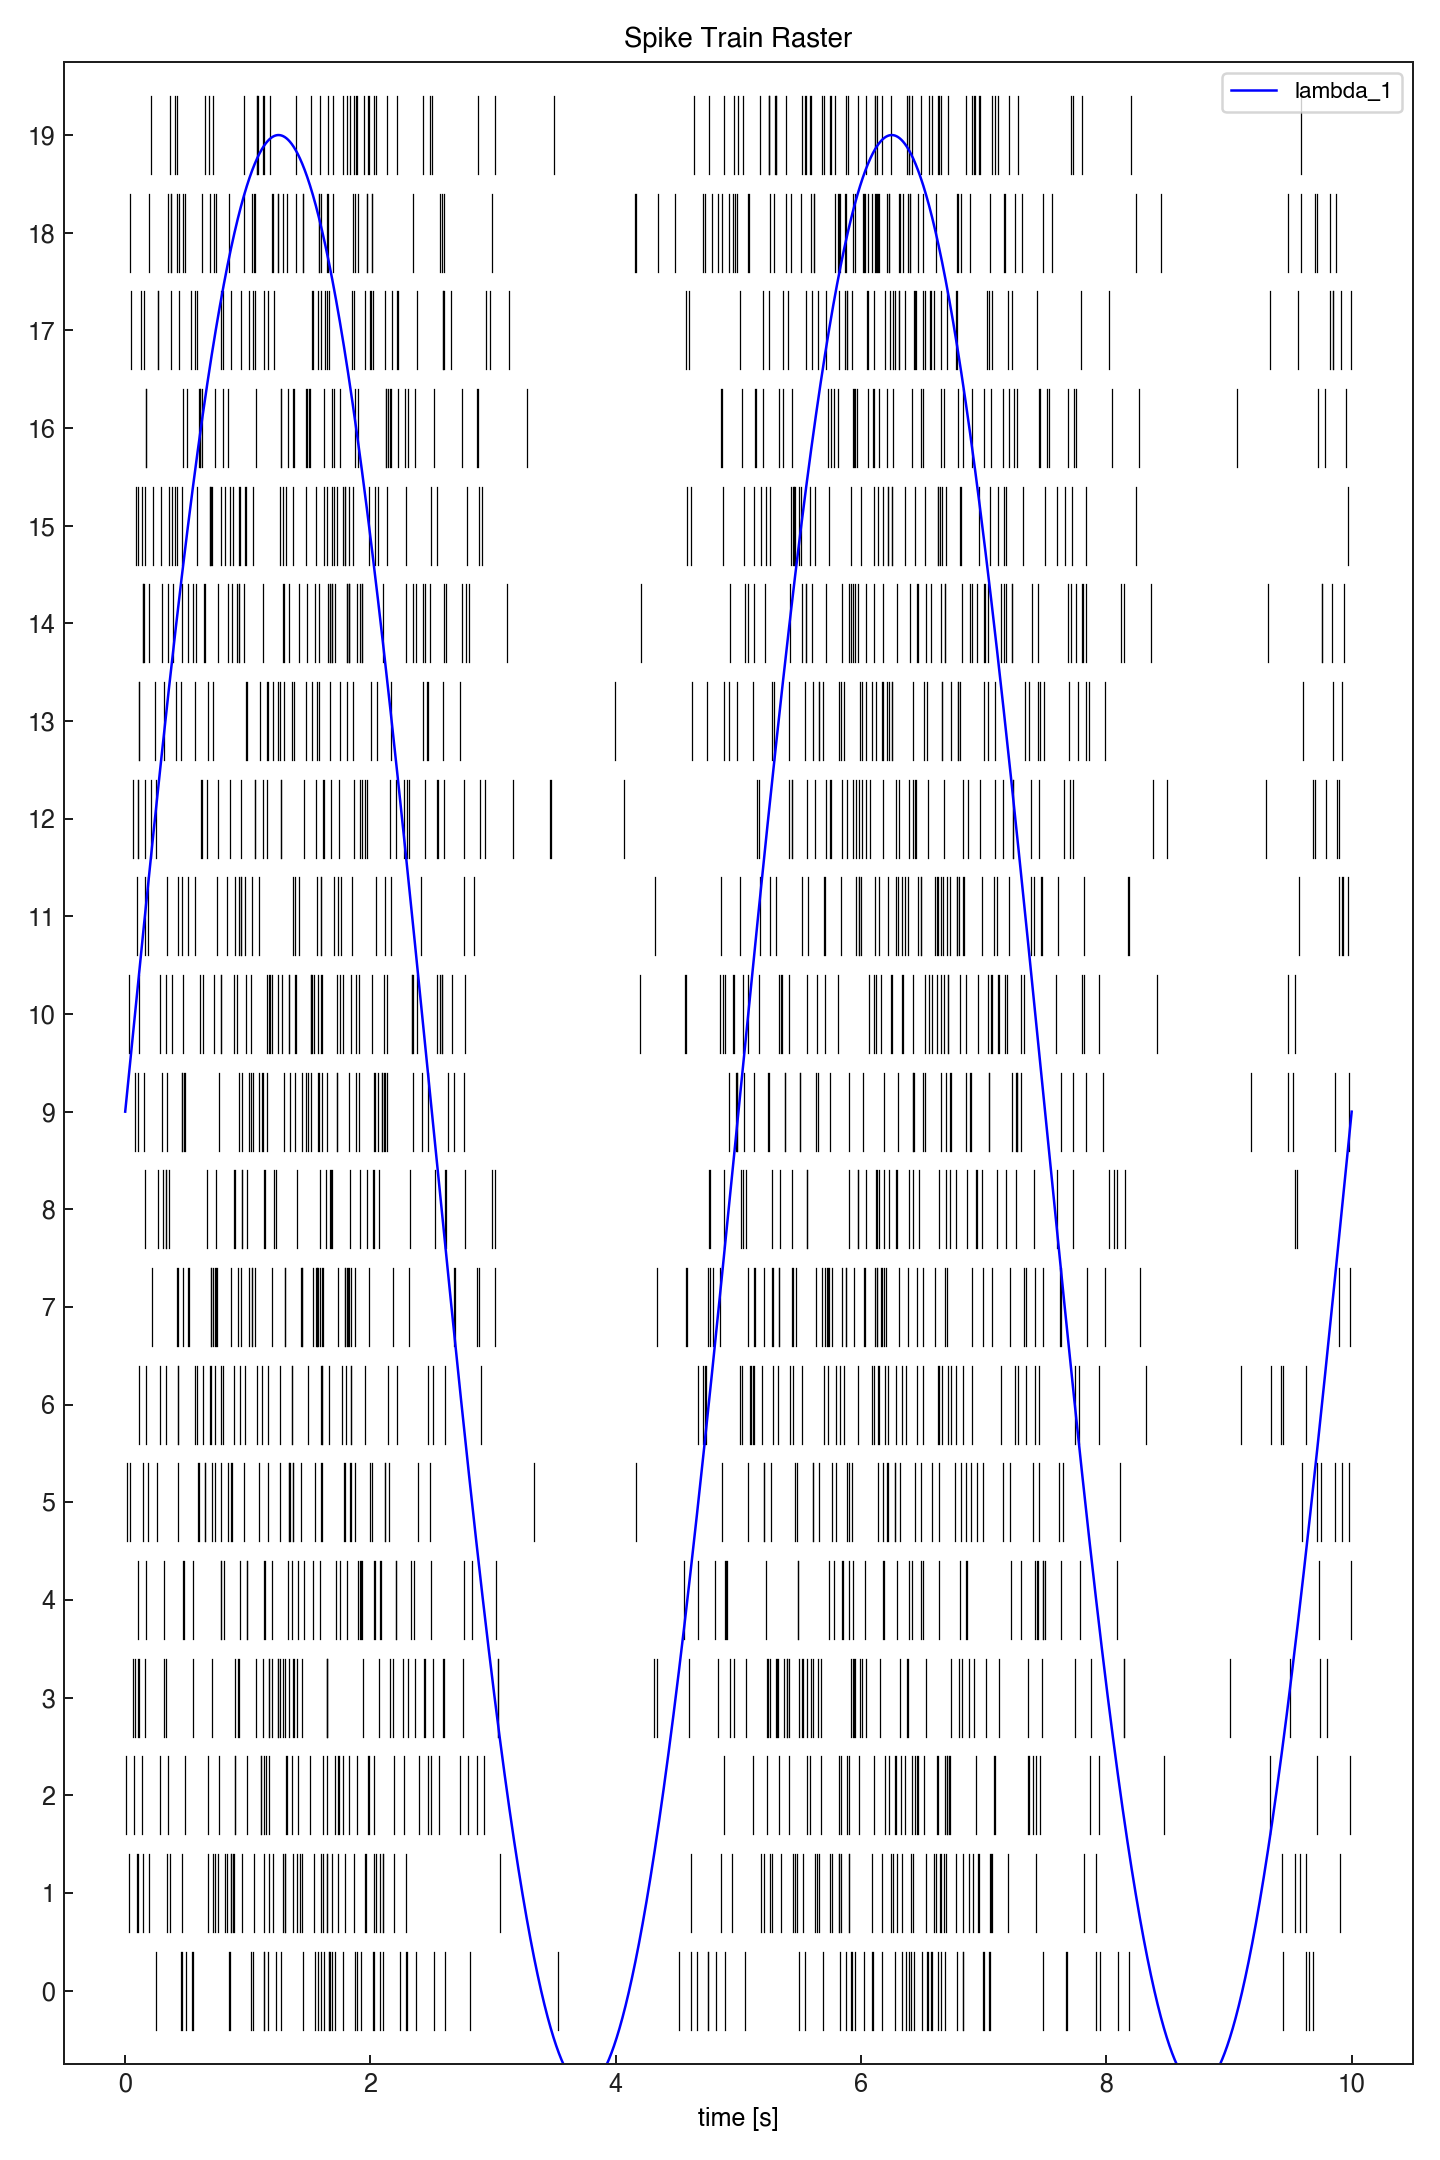

In [1]:
from pathlib import Path
import sys
REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from nstat import Covariate, nspikeTrain, nstColl, CIF
from nstat.notebook_figures import FigureTracker
np.random.seed(0)
OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
__tracker = FigureTracker(topic="PSTHEstimation", output_root=OUTPUT_ROOT, expected_count=2)
def capture(label, fn):
    fig = __tracker.new_figure(label); plt.close(fig); fn(); __tracker._active_fig = plt.gcf()


## Generate a known Conditional Intensity Function

We generated a known conditional intensity function (rate function) and generate distinct realizations of point processes consistent with this rate function. We use the method of thinning to simulate a point process.

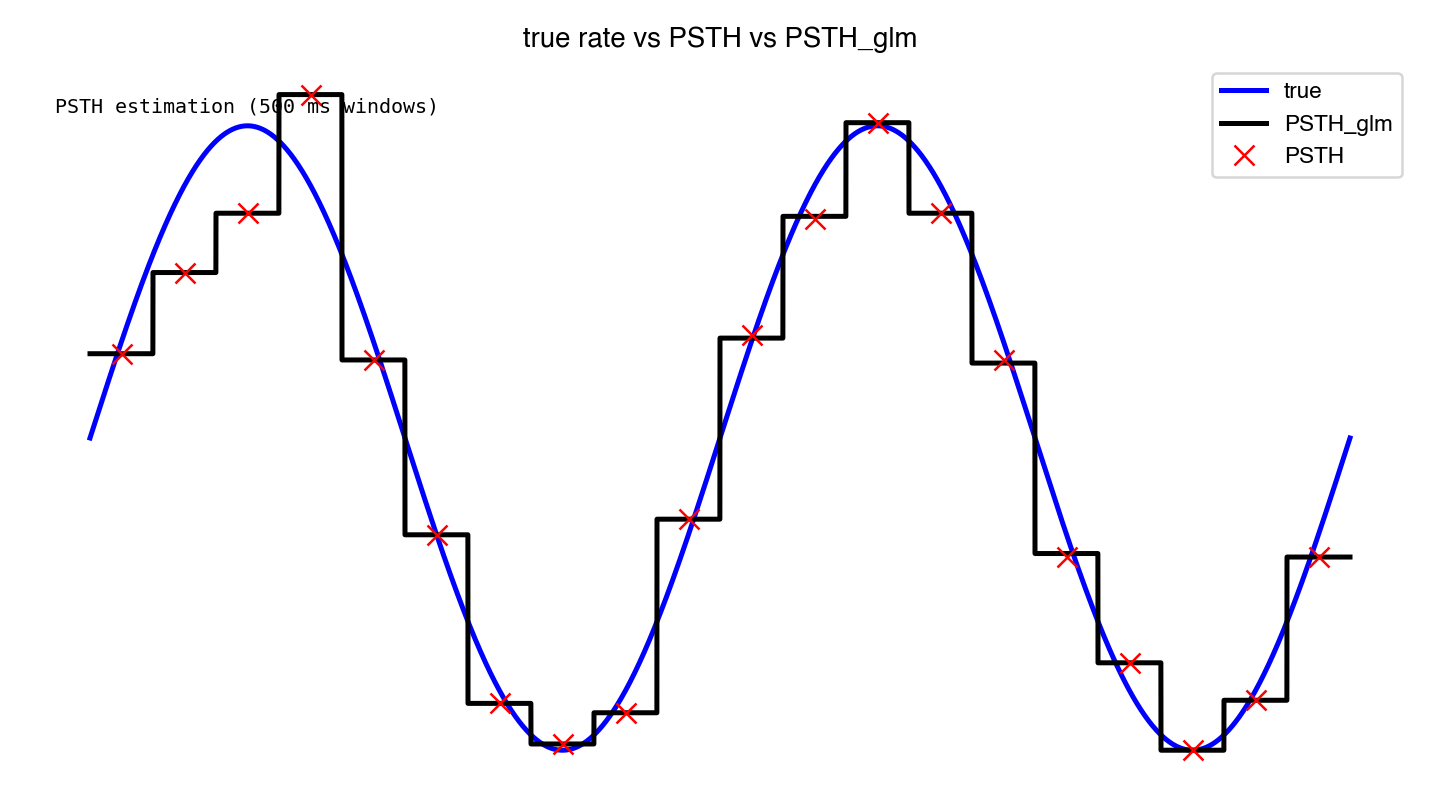

In [ ]:
# SECTION 1: Generate a known Conditional Intensity Function
delta = 0.001; Tmax = 10; time = np.arange(0, Tmax + delta, delta); f = 0.2
lambdaData = 10*np.sin(2*np.pi*f*time) + 10
lam = Covariate(time, lambdaData, "Lambda(t)", "time", "s", "Hz", ["lambda_1"])
spikeColl = CIF.simulateCIFByThinningFromLambda(lam, 20, seed=0)

capture("simulated raster with Lambda(t) overlay", lambda: spikeColl.plot())
# MATLAB parity: helpfiles/PSTHEstimation.m calls lambda.plot immediately after
# spikeColl.plot, drawing the sinusoidal rate on the same raster axes. MATLAB
# renders the overlay at its default linewidth (~0.5 pt), so the rate curve sits
# atop the raster ticks rather than dominating them.
_ax = plt.gca()
_ax.plot(np.asarray(lam.time).flatten(), np.asarray(lam.dataToMatrix()).flatten(), "b", linewidth=1.0, label="lambda_1")
_ax.legend(loc="upper right")


## Estimate the PSTH with 500ms windows

Note the mean of the PSTH estimated via the GLM model and the PSTH computed via standard methods agree precisely. The benefit of the GLM estimated PSTH is the presence of confidence bounds on the estimate. Both the standard and GLM PSTH are in close agreement with the "true" underlying rate function (conditional intensity function) used in this simulated example. Both the PSTH and PSTHGLM code could be updated in the future to allow for variable bin sizes (e.g. in the vein of Baysian Adaptive Regression Splines by Wallstrom, Leibner and Kass). Alternatively, porting of BARS to Matlab may allow for it to be easily integrated into the nSTAT toolbox.

In [ ]:
# SECTION 2: Estimate the PSTH with 500ms windows
__tracker.new_figure("PSTH estimation (500 ms windows)")
binsize = 0.5
psth = spikeColl.psth(binsize); psthGLM = spikeColl.psthGLM(binwidth=binsize)[0]
plt.plot(np.asarray(lam.time).flatten(), np.asarray(lam.dataToMatrix()).flatten(), "b", linewidth=2, label="true")
plt.plot(np.asarray(psthGLM.time).flatten(), np.asarray(psthGLM.dataToMatrix()).flatten(), "k", linewidth=2, label="PSTH_glm")
plt.plot(np.asarray(psth.time).flatten(), np.asarray(psth.dataToMatrix()).flatten(), "rx", markersize=8, label="PSTH")
plt.legend()
plt.title("true rate vs PSTH vs PSTH_glm"); plt.xlabel("time (s)"); plt.ylabel("Hz")
parity = {
    "psth_mean_hz": float(np.mean(np.asarray(psth.dataToMatrix()))),
    "psth_glm_mean_hz": float(np.mean(np.asarray(psthGLM.dataToMatrix()))),
    "lambda_mean_hz": float(np.mean(np.asarray(lam.dataToMatrix()))),
}
print(parity)
__tracker.finalize()
